# Deep learning applied to gravitational lensing

## Import parameters

In [3]:
import pandas as pd

df = pd.read_csv("mock_lenses_hsc.csv")
df

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,velDisp,x_source,y_source,boost,shear,shear_PA
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,378.07416,-0.279477,-0.477602,-1.0,0.022431,0.911779
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,329.32822,-0.074636,-0.380427,-3.0,0.059983,0.958381
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,333.96304,-0.133183,-0.277230,-3.0,0.038890,1.134869
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,369.14502,-0.133090,-0.034229,-4.0,0.005173,2.657499
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,359.74615,-0.318418,-0.027564,-4.0,0.043490,1.112804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,248.21088,0.057228,-0.057947,-4.0,0.054220,2.249565
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,228.52315,-0.070151,-0.063773,-3.0,0.029062,2.235106
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,245.66832,-0.018803,-0.008539,-1.0,0.045575,2.531362
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,204.68020,0.006797,-0.021310,-1.0,0.041806,2.955045


## Ellipticity

Compute $e_x$ and $e_y$

where :
$$e_x = \text{cos}(2\theta)\frac{1-q^2}{1+q^2} \quad \text{and} \quad e_y = \text{sin}(2\theta)\frac{1-q^2}{1+q^2}$$

and :
$$q = \frac{\sqrt{1 - \sqrt{e_x^2 + e_y^2}}}{\sqrt{1 + \sqrt{e_x^2 + e_y^2}}}$$


In [4]:
import numpy as np
df['ex'] = np.cos(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)
df['ey'] = np.sin(2 * df.PA) * (1 - df.q**2)/(1 + df.q**2)

In [5]:
df['qq'] = np.sqrt((1 - np.sqrt(df.ex **2 + df.ey**2)) / (1 + np.sqrt(df.ex **2 + df.ey**2)) )
df['diff'] = df.q - df.qq

## Shear

Compute $\gamma_{ext,1}$ and $\gamma_{ext,2}$
where:
$$\gamma_{ext, 1} = \text{cos}(2\theta) \ \gamma_{ext} \quad \text{and} \quad \gamma_{ext, 2} = \text{sin}(2\theta) \ \gamma_{ext}$$
and :
$$\gamma_{ext} = \sqrt{\gamma_{ext, 1}^2 + \gamma_{ext,2}^2}$$

In [6]:
df['gamma1'] = np.cos(2 * df.shear_PA) * df.shear
df['gamma2'] = np.sin(2 * df.shear_PA) * df.shear

## Distribution of the dataset

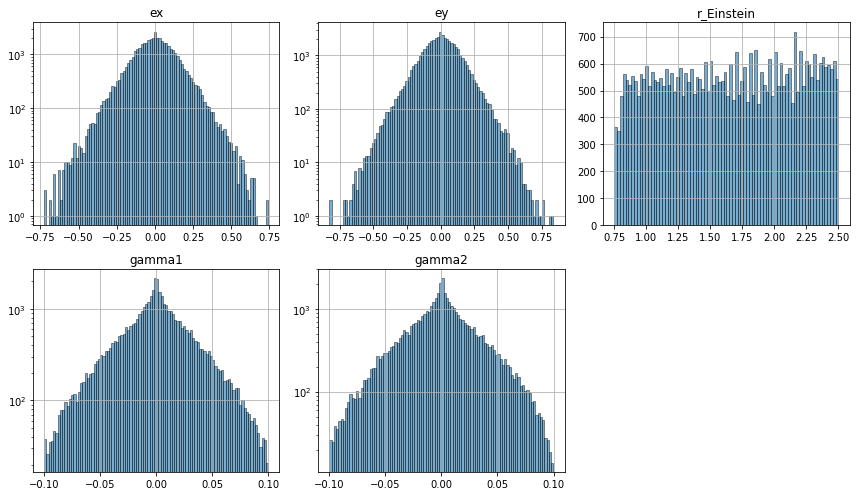

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()   
columns = ["ex", "ey", "r_Einstein", "gamma1", "gamma2"]

for i, col in enumerate(columns):
    if columns[i] == 'r_Einstein':
        axes[i].hist(df[col], bins=80, alpha=0.6, edgecolor='black',linewidth=0.7)
    else:
        axes[i].hist(df[col], bins=100, alpha=0.6, log = True, edgecolor='black',linewidth=0.7)
    axes[i].set_title(col)
    axes[i].grid(True)

# axes[-2].axis("off")
axes[-1].axis("off")

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/Dataset_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

## Images

In [8]:
import os
os.chdir("/home/rcanameras/data/mock_lenses_hsc/")
# os.chdir("/home/mbatt")

In [9]:
folders = [f for f in os.listdir() if 'csv' not in f]

dict_im = {}
for fold in folders: 
    for file in os.listdir(fold):
        if '.fits' in file:
            objID = int(file.split('_')[1])
            dict_im[objID] = [fold + "/" + file]

In [10]:
df_im = pd.DataFrame(dict_im).T
df_im = df_im.reset_index()
df_im.columns = ["objID", "location"]

In [11]:
df_full = df.merge(df_im, on = "objID", how = 'left')

In [12]:
df_sample = df_full#.sample(n=2000, random_state=42)

In [13]:
import os
os.chdir("/home/mbatt")

In [14]:
df_sample.sort_values(by = 'gamma1')

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
10846,12143,2324,3,-0.048889,0.046437,0.882302,0.356401,2.064032,2.946516,0.536476,...,-5.0,0.1,1.561423,0.094241,0.081464,0.882302,0.000000e+00,-0.099982,0.001874,final_hscsearch_2e3_7/lens_12143_source_2324_r...
23688,27629,1210,2,-0.048889,0.046437,0.909107,0.844472,1.556630,2.458530,0.389296,...,-2.0,0.1,1.561423,-0.011199,0.094343,0.909107,-1.110223e-16,-0.099982,0.001874,final_hscsearch_2e3_14/lens_27629_source_1210_...
20755,24047,7393,0,0.117094,-0.022303,0.771864,1.755716,1.675138,6.396018,0.449932,...,-4.0,0.1,1.556072,-0.236183,-0.091563,0.771864,0.000000e+00,-0.099957,0.002944,final_hscsearch_2e3_13/lens_24047_source_7393_...
37197,44043,1045,0,0.117094,-0.022303,0.952207,0.793206,1.038167,2.615449,0.356611,...,-1.0,0.1,1.556072,-0.000764,0.048928,0.952207,1.110223e-16,-0.099957,0.002944,final_hscsearch_2e3_23/lens_44043_source_1045_...
13135,14837,6332,0,-0.018424,0.002261,0.860088,1.914664,2.005392,6.335416,0.291249,...,-5.0,0.1,1.548447,-0.115586,-0.094958,0.860088,0.000000e+00,-0.099900,0.004468,final_hscsearch_2e3_8/lens_14837_source_6332_r...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,4332,1063,1,0.054320,0.016889,0.805468,2.657724,2.375967,2.677529,0.610158,...,-2.0,0.1,3.111103,0.120816,-0.175443,0.805468,0.000000e+00,0.099814,-0.006094,final_hscsearch_2e3_3/lens_4332_source_1063_r_...
5265,5827,6420,3,0.092128,0.093686,0.870879,0.775990,2.341105,4.265158,0.414054,...,-5.0,0.1,3.126737,0.002585,0.137354,0.870879,0.000000e+00,0.099956,-0.002971,final_hscsearch_2e3_3/lens_5827_source_6420_r_...
18367,21175,7197,0,0.003356,0.038650,0.717354,1.997383,1.756355,4.512842,0.592749,...,-5.0,0.1,0.012763,-0.210748,-0.241443,0.717354,0.000000e+00,0.099967,0.002552,final_hscsearch_2e3_11/lens_21175_source_7197_...
17589,20234,7125,0,-0.024370,0.008802,0.769233,0.058806,1.843589,5.029268,0.444768,...,-3.0,0.1,0.007984,0.254731,0.030099,0.769233,-1.110223e-16,0.099987,0.001597,final_hscsearch_2e3_11/lens_20234_source_7125_...


In [15]:
image_index = 9

## Images raw

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_1/lens_12_source_1225_r_0.fits


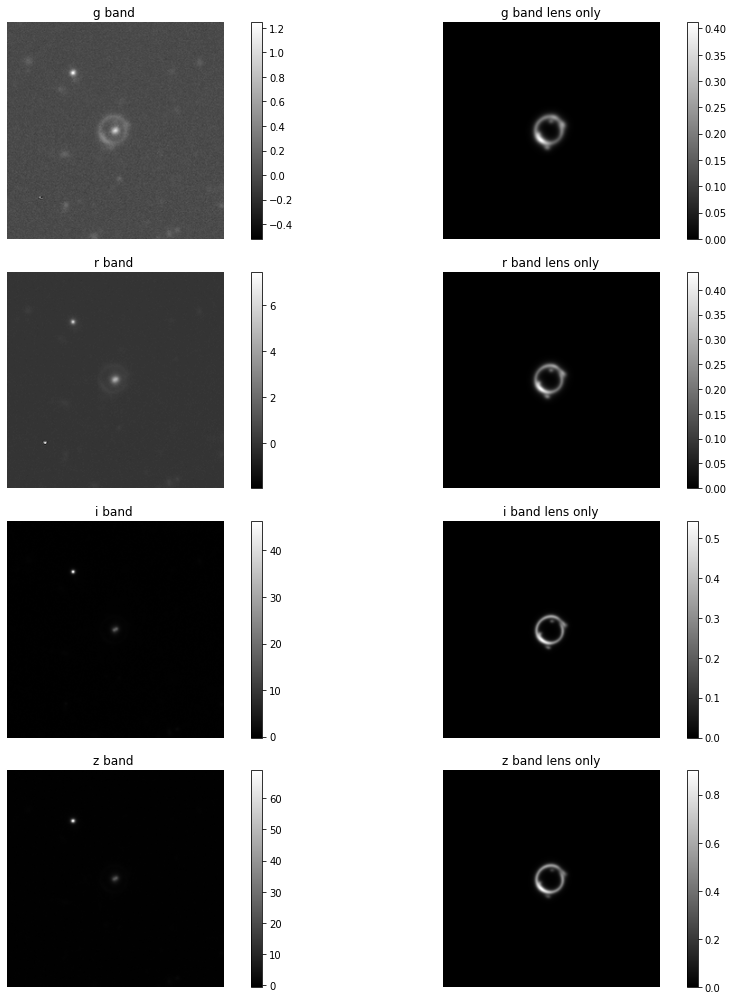

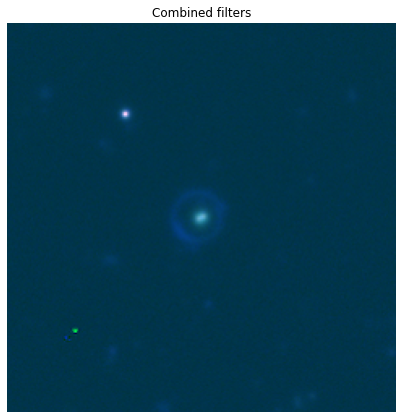

In [16]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, df_sample.location.values[image_index])
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
    
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
bandes = ['g', 'r', 'i', 'z']
typpe = ['', 'lens only']
for ax, img, idx in zip(axes.ravel(), images, range(1, len(images)+1)):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[(idx-1)//2]} band {typpe[(idx-1)%2]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/lenses_8_bands.png", dpi=300, bbox_inches="tight")
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
# plt.colorbar()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/lenses_color.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
import torch
from astropy.io import fits
import numpy as np

def save_fits_as_tensor(arr, save_path):
    # arr is dimension 8
    tensor = torch.tensor(arr, dtype=torch.float32)
    torch.save(tensor, save_path)

In [18]:
path_image = "/net/CLUSTER/VAULT/users/rcanameras/data/mock_lenses_hsc/"
save_path = "/net/CLUSTER/VAULT/users/mbatt/data/"

In [19]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location[35510:]):
#     x = torch.load("/home/mbatt/data/"+ ima_file.split('/')[1] + ".pt")
#     if x.shape[0] != 8:
# #         ima_file = 'final_hscsearch_2e3_23/lens_45869_source_1366_r_2.fits'
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

In [20]:
# import random
# from tqdm import tqdm
# import os

# w1, w2 = 40, 180 # image will be of dimension w2-w1 x w2-w1
# LL = [f for f in os.listdir(save_path)]

# for ima_file in tqdm(df_sample.location[:10]):
#     if ima_file.split('/')[1] + '.pt' not in LL:
#         with fits.open(path_image + ima_file) as hdul:
#             c = random.randint(0, w1)
#             images = [hdul[i].data[w1+c:w2+c,w1+c:w2+c] for i in range(1, len(hdul))]
#             arr = np.stack(images, axis=0)
#             save_fits_as_tensor(arr, save_path + ima_file.split('/')[1] + ".pt")

## Images reformated

Found FITS: 43734
Opening: /net/CLUSTER/VAULT/users/mbatt/data/lens_12_source_1225_r_0.fits.pt


/tmp/ipykernel_96714/2505060706.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images = torch.load(file)[::2]


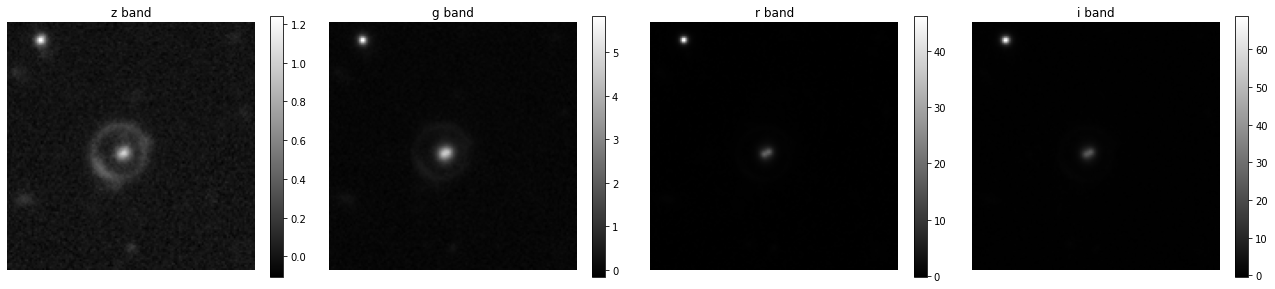

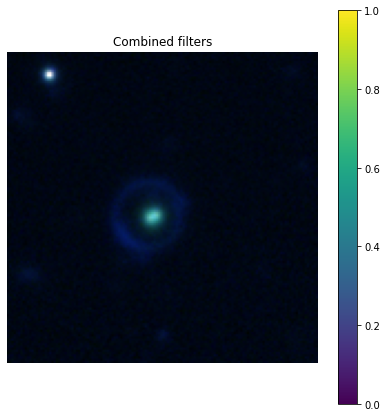

In [21]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder =  "/net/CLUSTER/VAULT/users/mbatt/data/"
fits_files = [f for f in os.listdir(folder)]
print("Found FITS:", len(fits_files))

file = os.path.join(folder, df_sample.location.values[image_index].split("/")[1] + ".pt")
images = torch.load(file)[::2]
print("Opening:", file)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    im = ax.imshow(img, origin='lower', cmap='gray')
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{bandes[idx-1]} band")
    ax.axis('off')

plt.tight_layout()
plt.show()

g = images[0]
r = images[1]
i = images[2]
z = images[3]
    
R, G, B = i,r,g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R), norm(G), norm(B)

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
plt.imshow(rgb, origin='lower')
plt.tight_layout()
plt.axis('off')
plt.title("Combined filters")
plt.colorbar()
plt.show()

# Deep learning models

In [22]:
df_sample

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
0,1,1090,0,0.038127,-0.083938,0.832873,1.099377,2.454128,3.127611,0.730786,...,-1.0,0.022431,0.911779,-0.106255,0.146359,0.832873,0.000000e+00,-0.005610,0.021719,final_hscsearch_2e3_1/lens_1_source_1090_r_0.fits
1,2,426,0,-0.082791,-0.109870,0.742644,1.852767,2.468242,5.798559,0.441585,...,-3.0,0.059983,0.958381,-0.244299,-0.154508,0.742644,-1.110223e-16,-0.020340,0.056429,final_hscsearch_2e3_1/lens_2_source_426_r_0.fits
2,3,2136,0,-0.054644,-0.008364,0.845785,2.936826,2.475322,4.785457,0.454826,...,-3.0,0.038890,1.134869,0.152219,-0.066075,0.845785,0.000000e+00,-0.025022,0.029771,final_hscsearch_2e3_1/lens_3_source_2136_r_0.fits
3,4,7141,0,-0.030885,-0.070501,0.857919,2.483655,2.456651,4.792636,0.819645,...,-4.0,0.005173,2.657499,0.038344,-0.147143,0.857919,0.000000e+00,0.002932,-0.004262,final_hscsearch_2e3_1/lens_4_source_7141_r_0.fits
4,5,7215,0,-0.038541,0.001391,0.899268,0.382301,2.497800,4.860585,0.703609,...,-4.0,0.043490,1.112804,0.076335,0.073224,0.899268,0.000000e+00,-0.026486,0.034495,final_hscsearch_2e3_1/lens_5_source_7215_r_0.fits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43728,51996,1083,1,0.012901,-0.058693,0.867499,1.836198,0.776824,0.827810,0.415259,...,-4.0,0.054220,2.249565,-0.121763,-0.071475,0.867499,0.000000e+00,-0.011475,-0.052992,final_hscsearch_2e3_26/lens_51996_source_1083_...
43729,51997,12,2,-0.001551,0.024924,0.808340,2.464540,0.756855,0.996663,0.422812,...,-3.0,0.029062,2.235106,0.045068,-0.204716,0.808340,0.000000e+00,-0.006970,-0.028214,final_hscsearch_2e3_26/lens_51997_source_12_r_...
43730,51998,11,0,0.006303,-0.002664,0.750802,2.697964,0.792795,1.037593,0.484768,...,-1.0,0.045575,2.531362,0.176209,-0.216331,0.750802,-1.110223e-16,0.015642,-0.042806,final_hscsearch_2e3_26/lens_51998_source_11_r_...
43731,51999,1273,0,0.046707,0.056492,0.853459,1.348237,0.786784,2.172062,0.494431,...,-1.0,0.041806,2.955045,-0.141833,0.067661,0.853459,0.000000e+00,0.038930,-0.015238,final_hscsearch_2e3_26/lens_51999_source_1273_...


In [23]:
dff = df_sample[['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey', 'location']]
dff = dff.set_index("location")

# Normalization of the parameters

In [24]:
cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']
dff[cols_to_norm] = (dff[cols_to_norm] - dff[cols_to_norm].min()) / (dff[cols_to_norm].max() - dff[cols_to_norm].min())

In [25]:
# cols_to_norm = ['r_Einstein', 'gamma1', 'gamma2', 'ex', 'ey']

# means = dff[cols_to_norm].mean()
# stds = dff[cols_to_norm].std()

# dff[cols_to_norm] = (dff[cols_to_norm] - means) / stds

In [26]:
dff = dff.sample(frac=1, random_state=42)

In [27]:
dff.to_csv('/home/mbatt/gravitational_lensing/ready_data.csv')

In [28]:
import pandas as pd
dff = pd.read_csv('/home/mbatt/gravitational_lensing/ready_data.csv', index_col = 0)

## Load data

In [29]:
from deep_learning_models import *
from deep_learning_models import LensDataset

In [30]:
import torch
from torch.utils.data import random_split

path_tensor = "/home/mbatt/data"
full_dataset = LensDataset_UNet(dff, path_tensor)

train_loader, val_loader, test_loader = full_dataset.split_data(training_pct = 0.6, # 60% for training
                                                                test_pct = 0.2, # 20% for test
                                                                batch_size = 32)

## Import Models

In [31]:
from deep_learning_models import UNetThenNN

In [32]:
import os
os.chdir("/home/mbatt/gravitational_lensing")

In [33]:
# model = ResNetMini()   
# model = ResNetHoliSmokes()
# model = BayesianResNetMini()
# model = UNet()
model = UNetThenResNet()
# model = UNetThenNN()

In [34]:
# v = viewer(model)
# v.show_model()
# # Image("resnetmini.png")

In [35]:
from process_training import Trainer
import warnings
warnings.filterwarnings("ignore")

In [36]:
Train_model = Trainer(model = model,
                      learning_rate = 1e-3,
                      scheduler_coef = 0.1                  
)

In [34]:
Train_model.run_unet_resnet(epochs = 100,
                training_set = train_loader, 
                validation_set = val_loader)

Epoch 1: train=0.0326, val=0.0322


KeyboardInterrupt: 

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import os

os.chdir("/home/mbatt/gravitational_lensing")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-5)

checkpoint = torch.load(f"{model.model_name}_15.pth", map_location=device)

model.load_state_dict(checkpoint["model"])
optimizer.load_state_dict(checkpoint["optimizer"])

start_epoch = checkpoint["epoch"] + 1

train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]


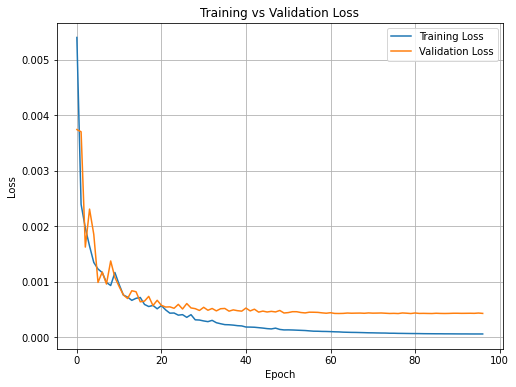

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_loss.png", dpi=300, bbox_inches="tight")
plt.show()


In [39]:
def rms(x):
    return torch.sqrt(torch.mean(x**2, dim=(-2, -1)))

def compute_noise(Liste, image, squarre):
    # Extract 5x5 corners
    tl = image[..., 0:squarre, 0:squarre]
    tr = image[..., 0:squarre, -squarre:]
    bl = image[..., -squarre:, 0:squarre]
    br = image[..., -squarre:, -squarre:]

    # RMS per corner → [B, 4]
    rms_tl = rms(tl)
    rms_tr = rms(tr)
    rms_bl = rms(bl)
    rms_br = rms(br)

    # Stack → [B, 4, 4]
    rms_all = torch.stack([rms_tl, rms_tr, rms_bl, rms_br], dim=-1)

    # Minimum RMS across corners → [B, 4]
    rms_min = rms_all.min(dim=-1).values

    Liste.append(rms_min.cpu())
    return Liste

In [40]:
Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

squarre = 20

for xb, yb in test_loader:   
    
    xb, xout = xb[0].to(device), xb[1].to(device)   # xb: [B, 4, 140, 140]
    yb = yb.to(device)
    
    Noise_t = compute_noise(Noise_t, xb, squarre)
    Noise_p = compute_noise(Noise_p, xout, squarre)

    # Signal = sum of all pixels in xout → [B, 4]
    signal_batch = xout.sum(dim=(-1, -2))
    Signal_p.append(signal_batch.cpu())
    
    signal_batch = xb.sum(dim=(-1, -2))
    Signal_t.append(signal_batch.cpu())

# Concatenate all batches
Noise_p = torch.cat(Noise_p, dim=0) 
Noise_t = torch.cat(Noise_t, dim=0) 
# Noise[Noise == 0] = 0.2 # shape [N, 4]
Signal_p = torch.cat(Signal_p, dim=0)   # shape [N, 4]
Signal_t = torch.cat(Signal_t, dim=0)   # shape [N, 4]

# Compute ratio
Ratio_p = Signal_p / Noise_p
Ratio_t = Signal_t / Noise_t


In [41]:
model.eval()
preds = []
targets = []

Noise_t = []
Noise_p = []
Signal_t = []
Signal_p = []


squarre = 20
criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:
        
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
#         out_lens = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)

        preds.append(outputs.cpu())
        targets.append(yb.cpu())
        
        Noise_t = compute_noise(Noise_t, xb, squarre)
        Noise_p = compute_noise(Noise_p, out_lens, squarre)

        # Signal = sum of all pixels in xout → [B, 4]
        signal_batch = out_lens.sum(dim=(-1, -2))
        Signal_p.append(signal_batch.cpu())

        signal_batch = xout.sum(dim=(-1, -2))
        Signal_t.append(signal_batch.cpu())

# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

# Concatenate all batches
Noise_p = torch.cat(Noise_p, dim=0) 
Noise_t = torch.cat(Noise_t, dim=0) 
# Noise[Noise == 0] = 0.2 # shape [N, 4]
Signal_p = torch.cat(Signal_p, dim=0)  # shape [N, 4]
Signal_t = torch.cat(Signal_t, dim=0) # shape [N, 4]

# Compute ratio
Ratio_p = Signal_p / Noise_p
Ratio_t = Signal_t / Noise_t

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0034, 0.0162, 0.0159, 0.0029, 0.0023])
Per-parameter R2: [0.9585172832012177, 0.3835170269012451, 0.3892882466316223, 0.7008364498615265, 0.7007501423358917]


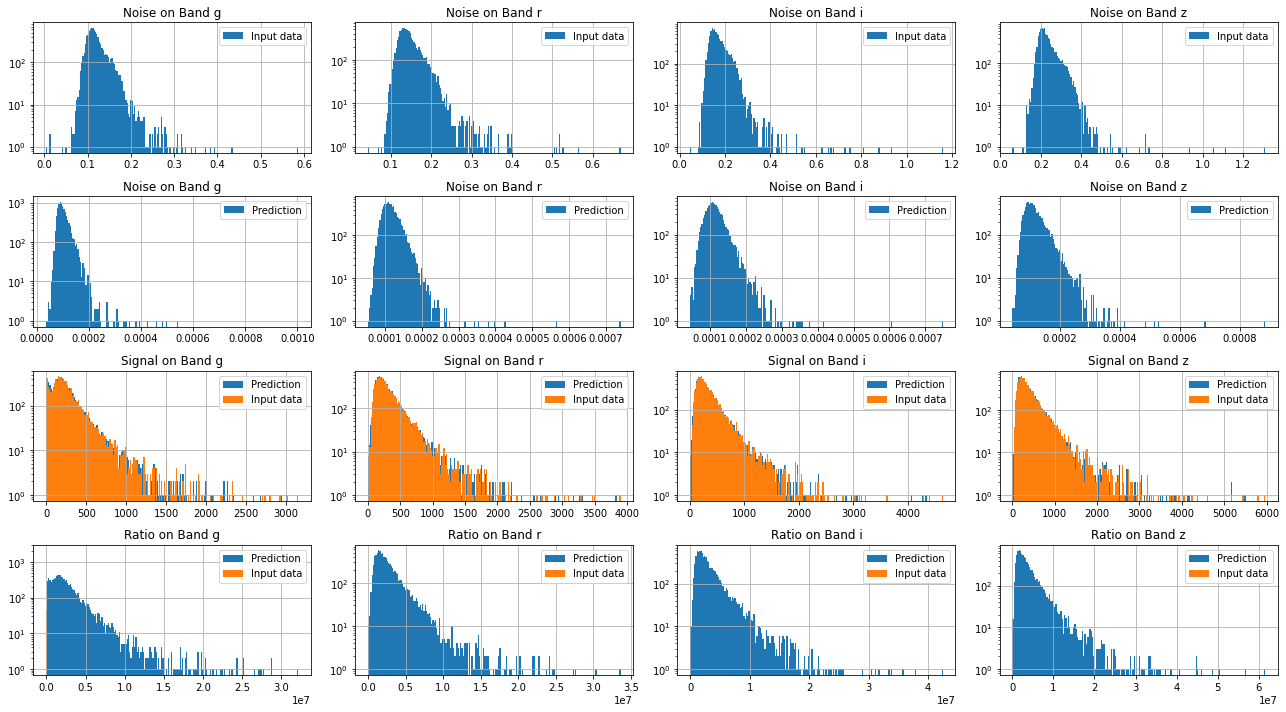

In [42]:
fig, ax = plt.subplots(4,4, figsize = (18,10))
bandes = ['g', 'r', 'i', 'z']
for i in range(4):
    ax[0,i].hist(Noise_t[:,i], bins= 200, label = 'Input data', log = True)
    ax[0,i].set_title(f"Noise on Band {bandes[i]}")
    ax[0,i].grid(True)
    ax[0,i].legend()
    
    ax[1,i].hist(Noise_p[:,i], bins= 200, label = 'Prediction', log = True)
    ax[1,i].set_title(f"Noise on Band {bandes[i]}")
    ax[1,i].grid(True)
    ax[1,i].legend()
    
    ax[2,i].hist(Signal_p[:,i], bins= 200, label = 'Prediction', log = True)
    ax[2,i].hist(Signal_t[:,i], bins= 200, label = 'Input data', log = True)
    ax[2,i].set_title(f"Signal on Band {bandes[i]}")
    ax[2,i].grid(True)
    ax[2,i].legend()
    
    ax[3,i].hist(Ratio_p[:,i], bins= 200, label = 'Prediction', log = True)
    ax[3,i].hist(Ratio_t[:,i], bins= 200, label = 'Input data', log = True)
    ax[3,i].set_title(f"Ratio on Band {bandes[i]}")
    ax[3,i].grid(True)
    ax[3,i].legend()

plt.tight_layout()
plt.show()
    

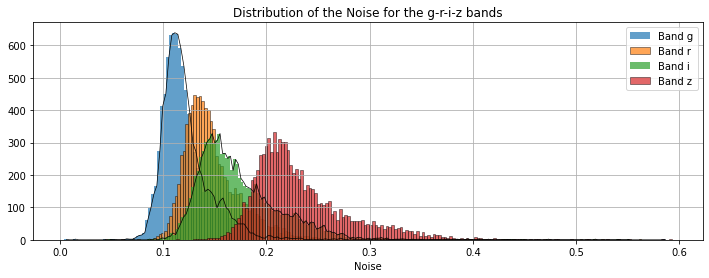

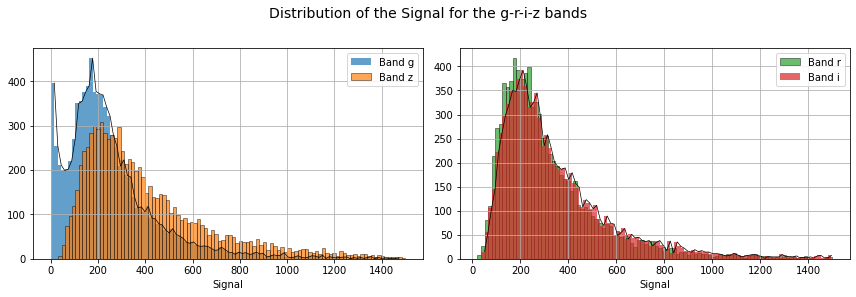

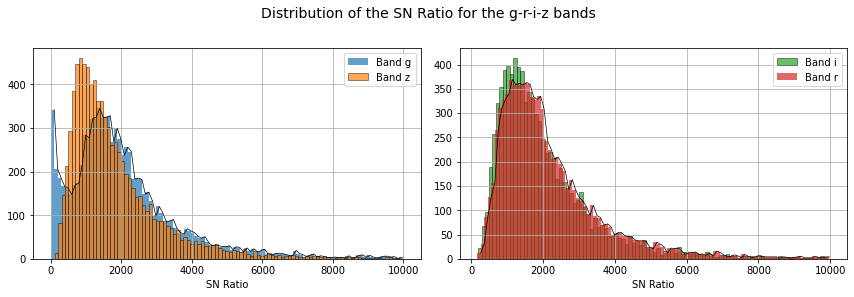

In [43]:
fig, axis = plt.subplots(1,1, figsize = (12,4))
bandes = ['g', 'r', 'i', 'z']

ax = axis
counts, bins, _ = ax.hist(Noise_t[:,0][Noise_t[:,0] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[0]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.hist(Noise_t[:,1][Noise_t[:,1] < 0.6], bins= 200, label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
counts, bins, _ = ax.hist(Noise_t[:,2][Noise_t[:,2] < 0.6], bins=200, alpha=0.7, label = f'Band {bandes[2]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.hist(Noise_t[:,3][Noise_t[:,3] < 0.6], bins= 200, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.set_title(f"Distribution of the Noise for the g-r-i-z bands")
ax.grid(True)
ax.set_xlabel('Noise')
ax.legend()
plt.show()

# ax = axis[1]
# counts, bins, _ = ax.hist(Signal_t[:,0][Signal_t[:,0] < 1500], bins=200, alpha=0.7, label = f'Band {bandes[0]}')
# ax.plot(bins[1:], counts, color='black', linewidth=0.7)
# ax.hist(Signal_t[:,1][Signal_t[:,1] < 1500], bins= 200, label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
# counts, bins, _ = ax.hist(Signal_t[:,2][Signal_t[:,2] < 1500], bins=200, alpha=0.7, label = f'Band {bandes[2]}')
# ax.plot(bins[1:], counts, color='black', linewidth=0.7)
# ax.hist(Signal_t[:,3][Signal_t[:,3] < 1500], bins= 200, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
# ax.set_title(f"Distribution of the Signal for the g-r-i-z bands")
# ax.grid(True)
# ax.set_xlabel('Signal')
# ax.legend()
# plt.tight_layout()
# # plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/noise_and_signal.png", dpi=300, bbox_inches="tight")
# plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
counts, bins, _ = ax.hist(Signal_t[:,0][Signal_t[:,0] < 1500], bins=100, alpha=0.7, label = f'Band {bandes[0]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.hist(Signal_t[:,3][Signal_t[:,3] < 1500], bins= 100, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('Signal')
ax.legend()

ax = axis[1]
# counts, bins, _ = ax.hist(Ratio_t[:,2][Ratio_t[:,2] < 80000],color = '#2ca02c', bins=200, alpha=0.7, label = f'Band {bandes[2]}')
# ax.plot(bins[:-1], counts, color='black', linewidth=0.7)
ax.hist(Signal_t[:,1][Signal_t[:,1] < 1500], bins= 100, color = '#2ca02c', label = f'Band {bandes[1]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

# ax.hist(Ratio_t[:,3][Ratio_t[:,3] < 80000], bins= 100, color = '#d62728', label = f'Band {bandes[3]}')#, alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
counts, bins, _ = ax.hist(Signal_t[:,2][Signal_t[:,2] < 1500],color = '#d62728', bins=100, alpha=0.7, label = f'Band {bandes[2]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.grid(True)
ax.set_xlabel('Signal')
ax.legend()

fig.suptitle("Distribution of the Signal for the g-r-i-z bands",
             fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(1,2, figsize = (12,4))
ax = axis[0]
counts, bins, _ = ax.hist(Ratio_t[:,0][Ratio_t[:,0] < 10000], bins=100, alpha=0.7, label = f'Band {bandes[0]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.hist(Ratio_t[:,3][Ratio_t[:,3] < 10000], bins= 100, label = f'Band {bandes[3]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
ax.grid(True)
ax.set_xlabel('SN Ratio')
ax.legend()

ax = axis[1]
# counts, bins, _ = ax.hist(Ratio_t[:,2][Ratio_t[:,2] < 80000],color = '#2ca02c', bins=200, alpha=0.7, label = f'Band {bandes[2]}')
# ax.plot(bins[:-1], counts, color='black', linewidth=0.7)
ax.hist(Ratio_t[:,2][Ratio_t[:,2] < 10000], bins= 100, color = '#2ca02c', label = f'Band {bandes[2]}', alpha = 0.7, edgecolor = 'black', linewidth = 0.6)

# ax.hist(Ratio_t[:,][Ratio_t[:,3] < 80000], bins= 100, color = '#d62728', label = f'Band {bandes[3]}')#, alpha = 0.7, edgecolor = 'black', linewidth = 0.6)
counts, bins, _ = ax.hist(Ratio_t[:,1][Ratio_t[:,1] < 10000],color = '#d62728', bins=100, alpha=0.7, label = f'Band {bandes[1]}')
ax.plot(bins[1:], counts, color='black', linewidth=0.7)
ax.grid(True)
ax.set_xlabel('SN Ratio')
ax.legend()

fig.suptitle("Distribution of the SN Ratio for the g-r-i-z bands",
             fontsize=14, y=1.02)
plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/sn_ratio.png", dpi=300, bbox_inches="tight")
plt.show()
    

In [44]:
model.eval()
preds_img = []
targets_img = []
inpute_img = []

pred_para = []
target_para = []

with torch.no_grad():
    for xb, yb in test_loader:
        
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        # ---- Forward pass ----
        out_lens = model.forward_unet(xb)
#         out_lens_b = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)
        
        preds_img.append(out_lens.cpu())
        targets_img.append(xout.cpu())
        inpute_img.append(xb.cpu())
        
        pred_para.append(outputs.cpu())
        target_para.append(yb.cpu())
        
        break

# concatenate all batches
preds_img = torch.cat(preds_img)      
targets_img = torch.cat(targets_img)  
inpute_img = torch.cat(inpute_img)

target_para = torch.cat(target_para)  
pred_para = torch.cat(pred_para)

In [45]:
batch_idx = 9
pred = preds_img[batch_idx]   # shape (4, 140, 140)
targ = targets_img[batch_idx]       # shape (4, 140, 140)
inpu = inpute_img[batch_idx]

true_value = target_para[batch_idx]
pred_value = pred_para[batch_idx]

In [46]:
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
true_value = true_value.cpu().numpy()
pred_value = pred_value.cpu().numpy()

# --- DENORMALIZATION ---
true_value = true_value * (df_max - df_min) + df_min
pred_value = pred_value * (df_max - df_min) + df_min

In [47]:
model.eval()
preds = []
targets = []
lens_only = []

criterion = nn.MSELoss(reduction="none")

with torch.no_grad():
    for xb, yb in test_loader:   # <-- use test_loader here
        xb, xout = xb[0].to(device), xb[1].to(device)
        yb = yb.to(device)

        out_lens = model.forward_unet(xb)
#         out_lens_b = torch.cat([out_lens, xb - out_lens], dim=1)
        outputs = model.forward_resnet(out_lens)
        
        ms = ((out_lens - xout)**2).mean(dim=(2, 3))
        lens_only.append(ms)
        preds.append(outputs.cpu())
        targets.append(yb.cpu())


# concatenate all batches
preds = torch.cat(preds)      # shape (N, 5)
targets = torch.cat(targets)  # shape (N, 5)
lens_only = torch.cat(lens_only)

# compute per-parameter MSE
loss = criterion(preds, targets)   # shape (N, 5)
mse = loss.mean(dim=0)             # shape (5,)

print("Per-parameter MSE:", mse)

# --- Compute R2 per parameter ---
y_true_np = targets.numpy()
y_pred_np = preds.numpy()

r2_scores = []
for i in range(5):
    ss_res = np.sum((y_true_np[:, i] - y_pred_np[:, i])**2)
    ss_tot = np.sum((y_true_np[:, i] - np.mean(y_true_np[:, i]))**2)
    r2 = 1 - ss_res / ss_tot
    r2_scores.append(r2)

print("Per-parameter R2:", r2_scores)


Per-parameter MSE: tensor([0.0034, 0.0162, 0.0159, 0.0029, 0.0023])
Per-parameter R2: [0.9585172832012177, 0.3835170269012451, 0.3892882466316223, 0.7008364498615265, 0.7007501423358917]


In [48]:
lens_only.shape

torch.Size([8746, 4])

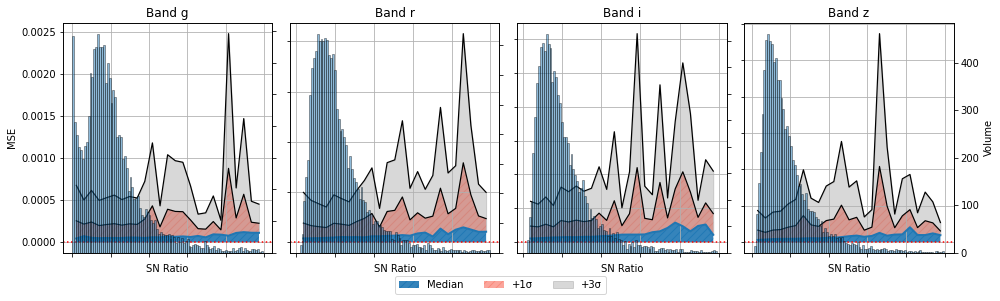

In [49]:
import numpy as np
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1,4, figsize=(14,4))
bandes = ['g', 'r', 'i', 'z']
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# Number of bins for smoothing
nbins = 25

for i in range(4):

    ax = axis[i%4]
    ax2 = ax.twinx()
#     ax.set_xscale('log')

    # Extract x and y
    x = Ratio_t[:, i]
    y = lens_only[:,i].cpu().numpy()
    
    mask = x < 10000     # boolean mask
    x = x[mask]     # keep only x < 2000
    y = y[mask]     # keep corresponding y values

    # Create bins
    bins = np.linspace(x.min(), x.max(), nbins+1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # Compute median and sigmas inside each bin
    medians = []
    sigma1 = []
    sigma3 = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        if mask.sum() > 0:
            y_bin = y[mask]
            medians.append(np.median(y_bin))
            sigma1.append(np.std(y_bin))
            sigma3.append(3*np.std(y_bin))
        else:
            medians.append(np.nan)
            sigma1.append(np.nan)
            sigma3.append(np.nan)

    medians = np.array(medians)
    sigma1 = np.array(sigma1)
    sigma3 = np.array(sigma3)

    # Plot median line
    ax.plot(centers, medians, color='C0', linewidth=2)
    
    ax.fill_between(
        centers,
        0,
        medians,
        color="C0",
        alpha=0.9,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="Median"
    )
    
    ax.fill_between(
        centers,
        medians,
        medians + sigma1,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="+1σ"
    )
    
    # Plot ±3 sigma band
    ax.fill_between(centers,
                    medians,
                    medians + sigma3,
                    color='gray', alpha=0.3, label="+3σ")
    
#     ax.plot(centers, medians - sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma1, color="black", linewidth=1.2)
#     ax.plot(centers, medians - sigma3, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma3, color="black", linewidth=1.2)
    ax.axhline(0, color="red", linestyle=":", linewidth=1.5)


    ax.grid(True)
    
    ax2.hist(x, bins=100, alpha=0.5,edgecolor='black',linewidth=0.7, label = "SN Ratio")

    if i %4 == 0:
        ax.set_ylabel(f'MSE')
    if i//4 == 0:
        ax.set_title(f'Band {bandes[i%5]}')
#         ax.legend()
    if i%4 == 3:
        ax2.set_ylabel("Volume")

    ax.set_xlabel('SN Ratio')
#     ax.set_xticklabels([])
    if i//4 != 4: 
        ax.set_xticklabels([])
    if i%4 != 0:
        ax.set_yticklabels([])
    if i%4 != 3:
        ax2.set_yticklabels([])

plt.tight_layout()
handles, labels = axis[0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.05),
           ncol=len(labels))
plt.show()


In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

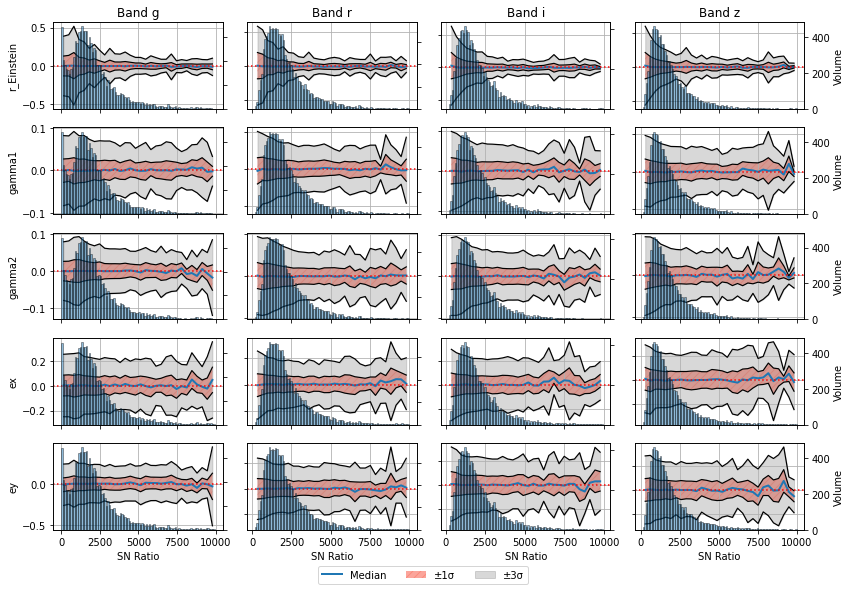

In [51]:
import numpy as np
import matplotlib.pyplot as plt

fig, axis = plt.subplots(5,4, figsize=(12,8))
bandes = ['g', 'r', 'i', 'z']
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# Number of bins for smoothing
nbins = 30

for i in range(20):

    ax = axis[i//4, i%4]
    ax2 = ax.twinx()
#     ax.set_xscale('log')

    # Extract x and y
    x = Ratio_t[:, i%4]
    y = y_true_denorm[:, i//4] - y_pred_denorm[:, i//4]
    
    mask = x < 10000          # boolean mask
    x = x[mask]     # keep only x < 2000
    y = y[mask]     # keep corresponding y values

    # Create bins
    bins = np.linspace(x.min(), x.max(), nbins+1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    # Compute median and sigmas inside each bin
    medians = []
    sigma1 = []
    sigma3 = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        if mask.sum() > 0:
            y_bin = y[mask]
            medians.append(np.median(y_bin))
            sigma1.append(np.std(y_bin))
            sigma3.append(3*np.std(y_bin))
        else:
            medians.append(np.nan)
            sigma1.append(np.nan)
            sigma3.append(np.nan)

    medians = np.array(medians)
    sigma1 = np.array(sigma1)
    sigma3 = np.array(sigma3)

    # Plot median line
    ax.plot(centers, medians, color='C0', linewidth=2, label = "Median")
    
    ax.fill_between(
        centers,
        medians - sigma1,
        medians + sigma1,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    # Plot ±3 sigma band
    ax.fill_between(centers,
                    medians - sigma3,
                    medians + sigma3,
                    color='gray', alpha=0.3, label="±3σ")
    
    ax.plot(centers, medians - sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma1, color="black", linewidth=1.2)
    ax.plot(centers, medians - sigma3, color="black", linewidth=1.2)
    ax.plot(centers, medians + sigma3, color="black", linewidth=1.2)
    ax.axhline(0, color="red", linestyle=":", linewidth=1.5)


    ax.grid(True)
    
    ax2.hist(x, bins=100, alpha=0.5,edgecolor='black',linewidth=0.7, label = "SN Ratio")

    if i %4 == 0:
        ax.set_ylabel(f'{names[i//4]}')
    if i//4 == 0:
        ax.set_title(f'Band {bandes[i%5]}')
#         ax.legend()
    if i%4 == 3:
        ax2.set_ylabel("Volume")
    if i//4 == 4:
        ax.set_xlabel('SN Ratio')
#     ax.set_xticklabels([])
    if i//4 != 4: 
        ax.set_xticklabels([])
    if i%4 != 0:
        ax.set_yticklabels([])
    if i%4 != 3:
        ax2.set_yticklabels([])

plt.tight_layout()
handles, labels = axis[0,0].get_legend_handles_labels()

fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.03),
           ncol=len(labels))
plt.show()


In [52]:
i = 0
names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

dr = pd.DataFrame({f'true {names[i]}' : y_true_denorm[:,i], f'pred {names[i]}' : y_pred_denorm[:,i]})
dr['res'] = abs(dr[f'true {names[i]}'] - dr[f'pred {names[i]}'])
dr.sort_values(by = 'res')

,true r_Einstein,pred r_Einstein,res
5722,1.031214,1.031197,0.000017
4769,1.908689,1.908664,0.000026
3472,1.219596,1.219560,0.000036
3371,1.993149,1.993188,0.000038
7470,1.672126,1.672071,0.000055
...,...,...,...
1570,2.434107,1.396241,1.037865
6428,2.461415,1.423200,1.038214
1959,2.416942,1.231548,1.185393
7427,0.783281,1.990505,1.207224


In [79]:
pos = 5722 # 67 #5722
cus = y_true_denorm[pos,0]
# loc = df_sample[df_sample.r_Einstein.round(7) == round(true_value[0],7)].location.values[0] # 2.15571801
loc = df_sample[df_sample.r_Einstein.round(6) == round(y_true_denorm[pos,0],6)].location.values[0] # 2.15571801

In [80]:
df_sample[df_sample.r_Einstein.round(6) == round(y_true_denorm[pos,0],6)]

,objID,objID_src,rot,x_lens,y_lens,q,PA,r_Einstein,z_source,z_lens,...,boost,shear,shear_PA,ex,ey,qq,diff,gamma1,gamma2,location
36879,43659,6959,0,-0.014647,-0.06078,0.964863,1.483275,1.031214,3.566673,0.731124,...,-4.0,0.004644,0.206285,-0.035207,0.006226,0.964863,1.110223e-16,0.004255,0.001862,final_hscsearch_2e3_22/lens_43659_source_6959_...


Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_22/lens_43659_source_6959_r_0.fits


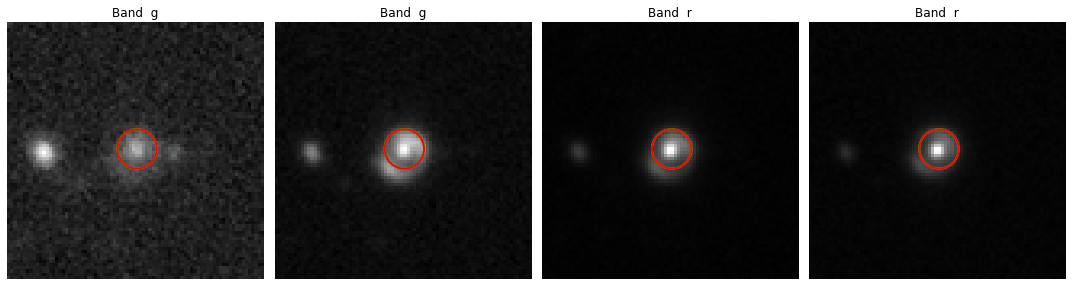

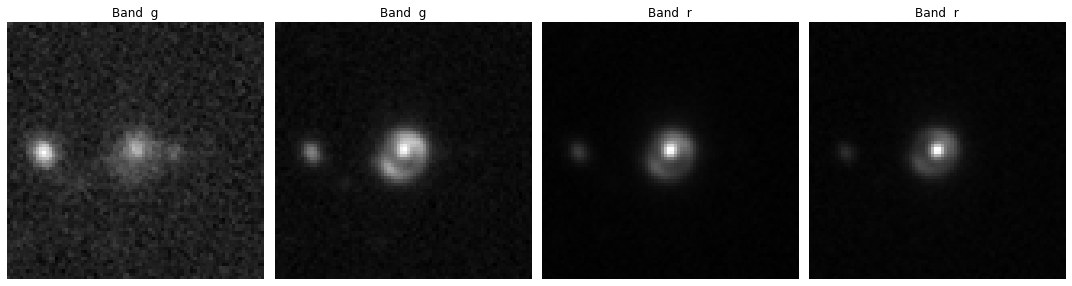

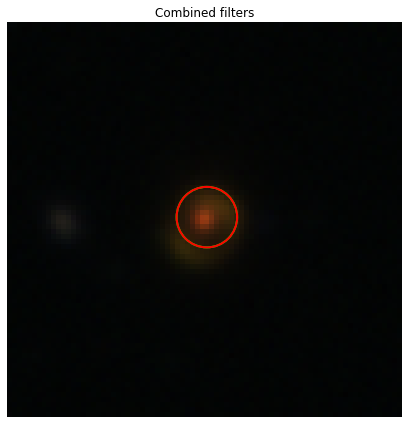

In [81]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import os
import random

folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, loc)
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']

w1, w2 = 80, 160 # image will be of dimension w2-w1 x w2-w1

for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    H, W = img.shape
    cx, cy = W/2, H/2

    # True Einstein radius (green)
    circle_true = plt.Circle((cx, cy), y_true_denorm[pos,0]/0.168,
                             color='lime', fill=False, linewidth=2)
    ax.add_patch(circle_true)

    # Predicted Einstein radius (red)
    circle_pred = plt.Circle((cx, cy), y_pred_denorm[pos,0]/0.168,
                             color='red', fill=False, linewidth=2)
    ax.add_patch(circle_pred)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']
for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

with fits.open(file) as hdul:
    g = hdul[1].data
    r = hdul[3].data
    i = hdul[5].data
    z = hdul[7].data
    
R, G, B = i, r, g

def norm(x):
    x = x - np.nanmin(x)
    x = x / np.nanmax(x)
    return x

Rn, Gn, Bn = norm(R)[w1:-w1,w1:-w1], norm(G)[w1:-w1,w1:-w1], norm(B)[w1:-w1,w1:-w1]

rgb = np.dstack([Rn, Gn, Bn])

plt.figure(figsize=(6,6))
ax = plt.gca()                     # get current axes

plt.imshow(rgb, origin='lower')
H, W = img.shape
cx, cy = W/2, H/2

# True Einstein radius (green)
circle_true = plt.Circle((cx, cy), y_true_denorm[pos,0]/0.168,
                         color='lime', fill=False, linewidth=2)
ax.add_patch(circle_true)

# Predicted Einstein radius (red)
circle_pred = plt.Circle((cx, cy), y_pred_denorm[pos,0]/0.168,
                         color='red', fill=False, linewidth=2)
ax.add_patch(circle_pred)

plt.title("Combined filters")
plt.axis('off')
plt.tight_layout()
plt.show()

Opening: /home/rcanameras/data/mock_lenses_hsc/final_hscsearch_2e3_22/lens_43659_source_6959_r_0.fits


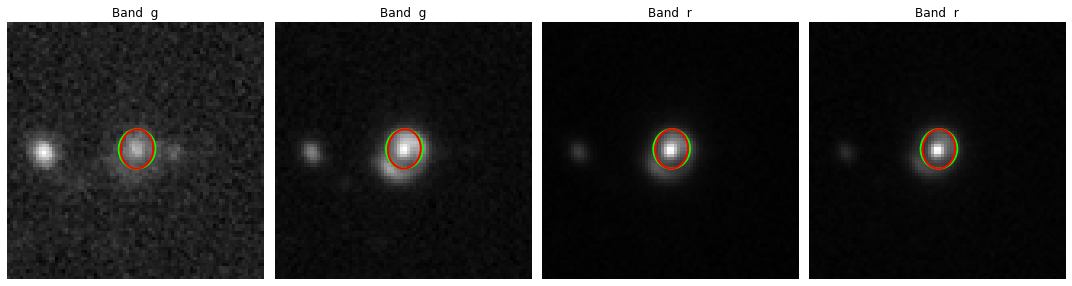

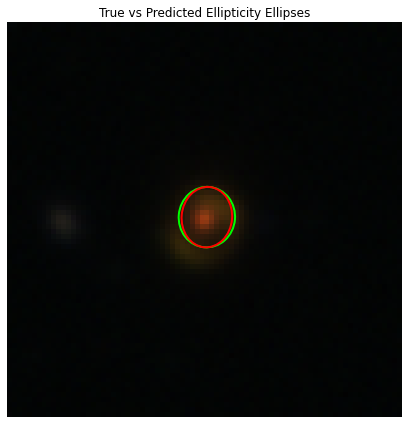

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# -----------------------------
# Helper: convert (ex, ey) → ellipse parameters
# -----------------------------
def ellipticity_to_axes(ex, ey, a_scale):
    e = np.sqrt(ex**2 + ey**2)            # ellipticity amplitude
    q = (1 - e) / (1 + e)                 # axis ratio b/a
    phi = 0.5 * np.arctan2(ey, ex)        # orientation
    a = a_scale                           # semi-major axis
    b = a * q                             # semi-minor axis
    return a, b, np.degrees(phi)

H, W = img.shape
cx, cy = W/2, H/2

# -----------------------------
# TRUE ellipse
# -----------------------------
ex_t = y_true_denorm[pos,3]
ey_t = y_true_denorm[pos,4]
a_scale_true = y_true_denorm[pos,0] / 0.168   # same scale as your circle

a_t, b_t, phi_t = ellipticity_to_axes(ex_t, ey_t, a_scale_true)

# -----------------------------
# PRED ellipse
# -----------------------------
ex_p = y_pred_denorm[pos,3]
ey_p = y_pred_denorm[pos,4]
a_scale_pred = y_pred_denorm[pos,0] / 0.168
a_p, b_p, phi_p = ellipticity_to_axes(ex_p, ey_p, a_scale_pred)


folder = "/home/rcanameras/data/mock_lenses_hsc"
file = os.path.join(folder, loc)
print("Opening:", file)

with fits.open(file) as hdul:
    images = [hdul[i].data for i in range(1, len(hdul))]
images = images[::2]    
fig, axes = plt.subplots(1, 4, figsize=(15, 10))
bandes = ['g', 'r', 'i', 'z']

w1, w2 = 80, 160 # image will be of dimension w2-w1 x w2-w1

for ax, img, idx in zip(axes.ravel(), images, range(0, len(images))):
    img = img[w1:-w1,w1:-w1]
    im = ax.imshow(img, origin='lower', cmap='gray')
#     fig.colorbar(im, ax=ax)
    ax.set_title(f"Band  {bandes[idx//2]}")
    ax.axis('off')
    
    ellipse_true = Ellipse(
    (cx, cy), width=2*a_t, height=2*b_t,
    angle=phi_t, edgecolor='lime', facecolor='none', linewidth=2)
    ax.add_patch(ellipse_true)

    ellipse_pred = Ellipse(
        (cx, cy), width=2*a_p, height=2*b_p,
        angle=phi_p, edgecolor='red', facecolor='none', linewidth=2
    )
    ax.add_patch(ellipse_pred)

plt.tight_layout()
plt.show()


plt.figure(figsize=(6,6))
ax = plt.gca()
# Show the RGB image
ax.imshow(rgb, origin='lower')

ellipse_true = Ellipse(
    (cx, cy), width=2*a_t, height=2*b_t,
    angle=phi_t, edgecolor='lime', facecolor='none', linewidth=2
)
ax.add_patch(ellipse_true)

ellipse_pred = Ellipse(
    (cx, cy), width=2*a_p, height=2*b_p,
    angle=phi_p, edgecolor='red', facecolor='none', linewidth=2
)
ax.add_patch(ellipse_pred)

ax.set_aspect('equal')
plt.title("True vs Predicted Ellipticity Ellipses")
plt.axis('off')
plt.tight_layout()
plt.show()


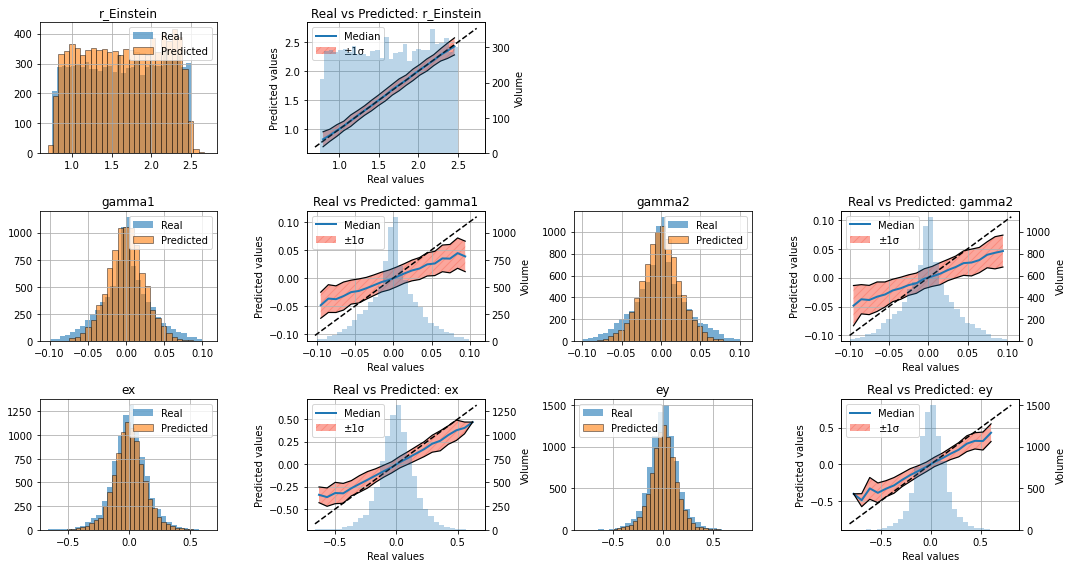

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize=(15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):

    # --- METRICS ---
    ss_res = np.sum((y_true_denorm[:, i] - y_pred_denorm[:, i])**2)
    ss_tot = np.sum((y_true_denorm[:, i] - np.mean(y_true_denorm[:, i]))**2)
    r2 = 1 - ss_res / ss_tot

    # Histogram comparison
    plt.subplot(3, 4, places[i][0])
    plt.hist(y_true_denorm[:, i], bins=30, alpha=0.6, label="Real")
    plt.hist(y_pred_denorm[:, i], bins=30, alpha=0.6, label="Predicted", edgecolor='black',linewidth=0.7)
    plt.title(f"{param_names[i]}")
    plt.legend()
    plt.grid(True)

    # Scatter plot real vs predicted
#     plt.subplot(5, 2, 2*i + 2)

    # Extract the variables
    x = y_true_denorm[:, i]
    y = y_pred_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Predicted values")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    
    # 1:1 line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax1.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Real vs Predicted: {param_names[i]}")
#     plt.grid(True)
#     plt.legend()


plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/UNet_8_resnet_1to1.png", dpi=300, bbox_inches="tight")
plt.show()


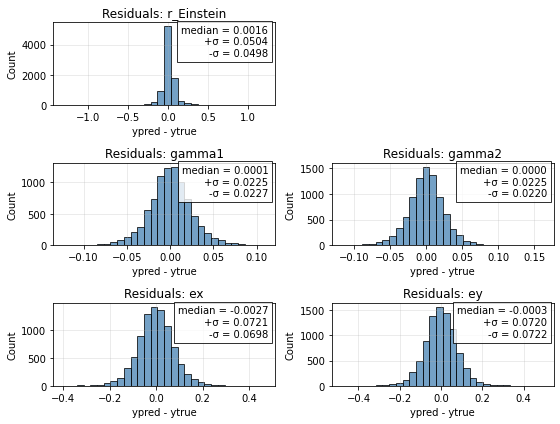

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- Min/max used for normalization ---
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values
scale = df_max - df_min   # range for each parameter

# --- Convert to numpy ---
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * scale + df_min
y_pred_denorm = y_pred * scale + df_min

# --- Compute denormalised errors ---
error_denorm = y_pred_denorm - y_true_denorm

# --- Asymmetric statistics ---
medians = np.median(error_denorm, axis=0)
p16 = np.percentile(error_denorm, 16, axis=0)
p84 = np.percentile(error_denorm, 84, axis=0)

sigma_minus = medians - p16
sigma_plus  = p84 - medians

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(8, 6))
axes = axes.flatten()  
poss = [1,3,4,5,6]

for i in range(error_denorm.shape[1]):
    plt.subplot(3, 2, poss[i])
    plt.hist(error_denorm[:, i], bins=30, alpha=0.75,
             color="steelblue", edgecolor="black")
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("ypred - ytrue")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # --- Add text box with denormalised stats ---
    text = (
        f"median = {medians[i]:.4f}\n"
        f"+σ = {sigma_plus[i]:.4f}\n"
        f"-σ = {sigma_minus[i]:.4f}"
    )

    plt.text(
        0.97, 0.97, text,
        transform=plt.gca().transAxes,
        fontsize=10,
        ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

plt.tight_layout()
axes[1].axis("off")
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_hist_residus.png", dpi=300, bbox_inches="tight")
plt.show()

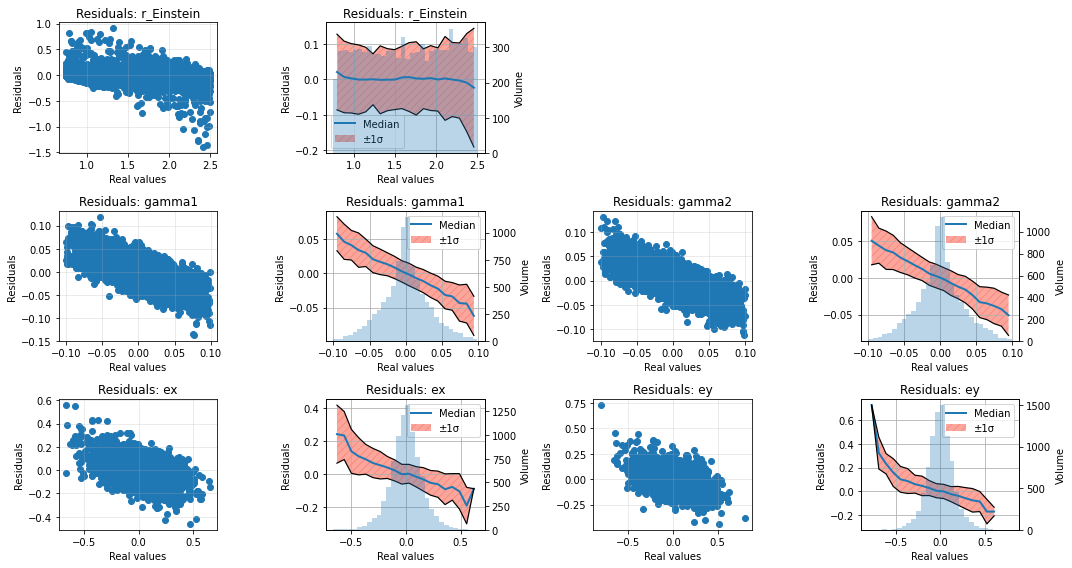

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Min/max used for normalization
df_min = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].min().values
df_max = df_sample[["r_Einstein", "gamma1", "gamma2", "ex", "ey"]].max().values

# Convert to numpy
y_true = targets.numpy()
y_pred = preds.numpy()

# --- DENORMALIZATION ---
y_true_denorm = y_true * (df_max - df_min) + df_min
y_pred_denorm = y_pred * (df_max - df_min) + df_min
error_denorm = y_pred_denorm - y_true_denorm

param_names = ["r_Einstein", "gamma1", "gamma2", "ex", "ey"]

plt.figure(figsize= (15, 8))
places = [(1,2), (5,6), (7,8), (9,10), (11,12)]

for i in range(5):
    plt.subplot(3, 4, places[i][0])
    plt.scatter(y_true_denorm[:,i], error_denorm[:,i])
    plt.title(f"Residuals: {param_names[i]}")
    plt.xlabel("Real values")
    plt.ylabel("Residuals")
    plt.grid(alpha=0.3)
    
    # Extract the variables
    x = y_true_denorm[:, i]
    y = error_denorm[:, i]
    
    # Define number of bins
    nbins = 20

    # Compute bins
    bins = np.linspace(x.min(), x.max(), nbins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    medians = []
    sigmas = []

    for j in range(nbins):
        mask = (x >= bins[j]) & (x < bins[j+1])
        y_bin = y[mask]

        if len(y_bin) > 0:
            medians.append(np.median(y_bin))
            sigmas.append(np.std(y_bin))
        else:
            medians.append(np.nan)
            sigmas.append(np.nan)

    medians = np.array(medians)
    sigmas = np.array(sigmas)
    
    ax1 = plt.subplot(3, 4,  places[i][1])
    ax2 = ax1.twinx()

    # Plot median curve
    ax1.plot(bin_centers, medians, color="C0", lw=2, label="Median")
    ax1.set_ylabel("Residuals")
    ax1.grid(True)

    # Plot ±1σ band
    ax1.fill_between(
        bin_centers,
        medians - sigmas,
        medians + sigmas,
        color="salmon",
        alpha=0.7,
        hatch="///",          # crosshatch style
        linewidth=0.0,        # avoid thick borders around the whole patch
        label="±1σ"
    )
    
    ax1.plot(bin_centers, medians - sigmas, color="black", linewidth=1.2)
    ax1.plot(bin_centers, medians + sigmas, color="black", linewidth=1.2)
    ax2.hist(y_true_denorm[:, i], bins=30, alpha=0.3)
    ax2.set_ylabel("Volume")
    
    ax1.set_xlabel("Real values")
    ax1.legend()
    plt.title(f"Residuals: {param_names[i]}")

plt.tight_layout()
# plt.savefig("/net/CLUSTER/VAULT/users/mbatt/gravitational_lensing/plots/unet_8_resnet_heteroscedastic.png", dpi=300, bbox_inches="tight")
plt.show()
